In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\System -02\Downloads\HR Employee Cleaning using  Power Query 01..csv')
df.columns = df.columns.str.lower().str.strip()
df.drop_duplicates(inplace = True)
df.dropna(subset=['salary'],inplace=True)
df['salary']=pd.to_numeric(df['salary'].astype(str).str.replace('[^0-9.]','',regex = True),errors='coerce')
df.dropna(subset=['salary'],inplace=True)

In [4]:
for col in df.select_dtypes(include=['object','string']).columns:
    df[col]=df[col].apply(
        lambda x: x.strip().lower().title() if isinstance(x,str)else x
    )

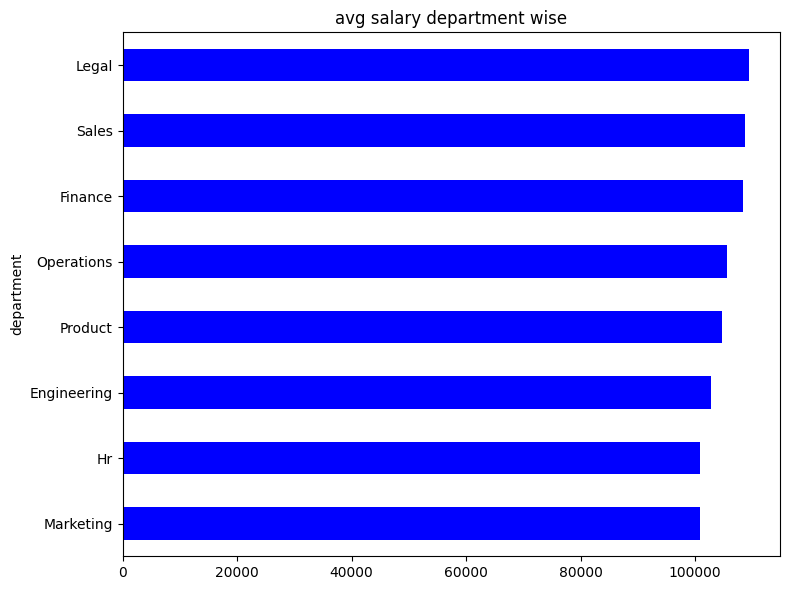

In [5]:
plt.figure(figsize=(8,6))
df.groupby('department')['salary'].mean().sort_values().plot(kind = 'barh',color ='blue')
plt.title('avg salary department wise')
plt.tight_layout()
plt.show()

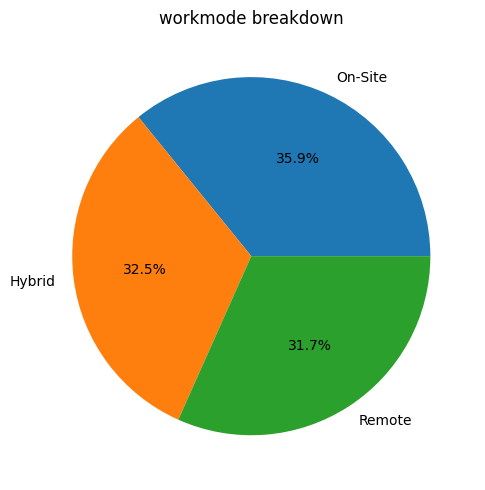

In [6]:
plt.figure(figsize=(5,5))
df['workmode'].value_counts().plot(kind='pie',autopct='%1.1f%%')   
plt.title('workmode breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [7]:
unique_values= {col:df[col].unique() for col in df.columns}

In [8]:
df['employeename']=(df['employeename'].str.replace(r'[^a-zA-Z\s]','',regex=True).str.strip().str.title())


In [9]:
df['age']=df['age'].fillna(df['age'].median())

In [10]:
df['employeename']=df['employeename'].fillna('Employee')
df['gender']=df['gender'].fillna('Unknown')


In [11]:
df = df.dropna(subset=['attrition'])

In [12]:
colse = [
    'workmode','status','city','educationlevel','jobtitle','department'
]
for col in colse:
    df[col]=df[col].astype(str).str.strip().str.lower().str.title()

In [13]:
colse = [
    'workmode','status','city','educationlevel','jobtitle','department'
]
for col in colse:
    df[col] =df[col].apply(lambda x: x.strip().lower().title() if isinstance(x,str)else x)
    
df[colse]=df[colse].fillna('Unknown')

In [14]:
df.isnull().sum().sort_values(ascending=False)

employeeid          0
experienceyears     0
attrition           0
status              0
joiningdate         0
projectshandled     0
leavestaken         0
performancescore    0
salary              0
employeename        0
city                0
educationlevel      0
jobtitle            0
department          0
age                 0
gender              0
workmode            0
dtype: int64

In [16]:
from sqlalchemy import create_engine
username="postgres"
password="nikku2004"
host="localhost"
port="5432"
database="HR"
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
df.to_sql("hr_employee",engine,if_exists="replace",index=False)
print("done")

done
